# 🏠 Tunisia Real Estate — Full Pre-processing & ML Price Prediction
### Philosophy: **Zero rows dropped.** Outliers are capped (Winsorization). All missing values are imputed using advanced methods.
---
**Dataset:** 8,129 Tunisian real estate listings with 26 features  
**Target:** `price_tnd` — property price in Tunisian Dinar  
**Strategy:** Impute → Engineer → Encode → Model → Evaluate


## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy import stats

# Imputers
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer

# Preprocessing
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.linear_model import BayesianRidge, Ridge

# Models
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

# Dark theme
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d2e",
    "axes.edgecolor":   "#2d2f45",
    "text.color":       "#e2e8f0",
    "axes.labelcolor":  "#e2e8f0",
    "xtick.color":      "#e2e8f0",
    "ytick.color":      "#e2e8f0",
    "grid.color":       "#2d2f45",
    "axes.grid":        True,
    "font.size":        10,
})
ACCENT, GREEN, ORANGE, RED = "#7c6af7", "#4ade80", "#fb923c", "#f87171"
print("✅ All imports ready")


✅ All imports ready


## 1. Load Data

In [2]:
df = pd.read_csv("dataSetFull.csv")
print(f"Shape: {df.shape}")
df.head(3)


Shape: (8129, 26)


,id,price_tnd,price_eur,location,city,governorate,Area,pieces,room,bathroom,...,garden,concierge,beach_view,mountain_view,pool,elevator,furnished,equipped_kitchen,central_heating,air_conditioning
0,b9e1c759-d149-46e8-9765-d8c198a13ff0,NaN,NaN,Cité El Bassatine Ancien,Boumhel Bassatine,Ben Arous,NaN,27.0,8.0,NaN,...,0,0,0,0,0,0,0,0,0,0
1,863e62e5-0bfe-49f3-ad97-e0ae91be68e9,3250000.0,1007500.0,El Kantaoui,Hammam Sousse,Sousse,1000.0,26.0,16.0,14.0,...,0,1,1,0,0,1,1,1,1,1
2,0048e6da-9aec-4ebe-8ee1-1ad7cd0015e6,2000000.0,620000.0,Sousse Corniche,Sousse Ville,Sousse,932.0,24.0,24.0,10.0,...,0,0,0,0,0,0,1,1,1,1


In [3]:
# Missing value audit
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
summary = pd.DataFrame({"Missing Count": miss, "% Missing": miss_pct})
summary[summary["Missing Count"] > 0].sort_values("% Missing", ascending=False)


,Missing Count,% Missing
age,4145,50.99
price_tnd,1708,21.01
price_eur,1708,21.01
city,1316,16.19
pieces,1189,14.63
state,1100,13.53
bathroom,659,8.11
room,409,5.03
Area,185,2.28
latt,35,0.43


## 2. Exploratory Data Analysis

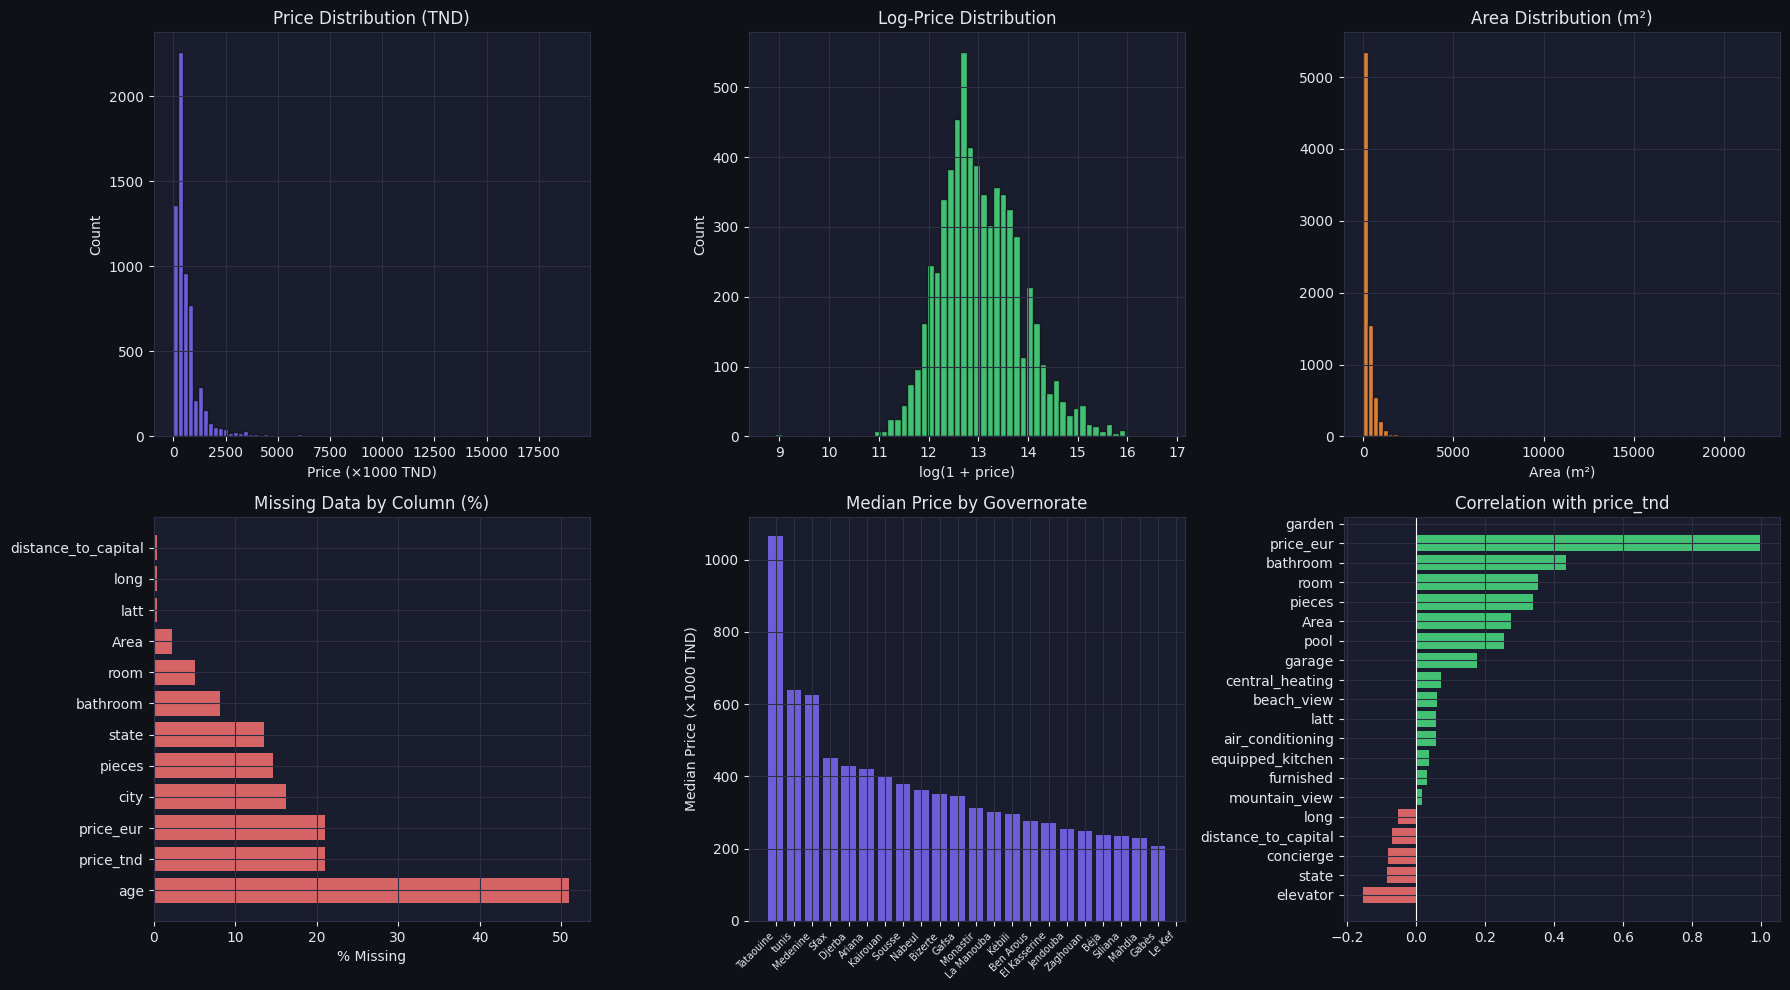

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Price distribution
axes[0].hist(df["price_tnd"].dropna() / 1000, bins=80, color=ACCENT, edgecolor="#0f1117", alpha=0.85)
axes[0].set_title("Price Distribution (TND)")
axes[0].set_xlabel("Price (×1000 TND)")
axes[0].set_ylabel("Count")

# Log price
axes[1].hist(np.log1p(df["price_tnd"].dropna()), bins=60, color=GREEN, edgecolor="#0f1117", alpha=0.85)
axes[1].set_title("Log-Price Distribution")
axes[1].set_xlabel("log(1 + price)")
axes[1].set_ylabel("Count")

# Area
axes[2].hist(df["Area"].dropna(), bins=80, color=ORANGE, edgecolor="#0f1117", alpha=0.85)
axes[2].set_title("Area Distribution (m²)")
axes[2].set_xlabel("Area (m²)")

# Missing data
miss_cols = df.isnull().sum()
miss_cols = miss_cols[miss_cols > 0].sort_values(ascending=False)
axes[3].barh(miss_cols.index, miss_cols.values / len(df) * 100, color=RED, alpha=0.85)
axes[3].set_title("Missing Data by Column (%)")
axes[3].set_xlabel("% Missing")

# Median price by governorate
gov_price = df.groupby("governorate")["price_tnd"].median().sort_values(ascending=False)
axes[4].bar(gov_price.index, gov_price.values / 1000, color=ACCENT, alpha=0.85)
axes[4].set_title("Median Price by Governorate")
axes[4].set_xticklabels(gov_price.index, rotation=45, ha="right", fontsize=7)
axes[4].set_ylabel("Median Price (×1000 TND)")

# Correlation with price_tnd
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()["price_tnd"].drop("price_tnd").sort_values()
axes[5].barh(corr.index, corr.values,
             color=[GREEN if v > 0 else RED for v in corr.values], alpha=0.85)
axes[5].set_title("Correlation with price_tnd")
axes[5].axvline(0, color="white", linewidth=0.8)

plt.tight_layout()
plt.show()


## 3. Drop Redundant / ID Columns
- `price_eur` is a direct linear transform of `price_tnd` → would cause data leakage  
- `id` is a UUID with zero predictive value


In [5]:
df.drop(columns=["price_eur", "id"], inplace=True)
print(f"Shape after dropping id & price_eur: {df.shape}")
print("Remaining columns:", df.columns.tolist())


Shape after dropping id & price_eur: (8129, 24)
Remaining columns: ['price_tnd', 'location', 'city', 'governorate', 'Area', 'pieces', 'room', 'bathroom', 'age', 'state', 'latt', 'long', 'distance_to_capital', 'garage', 'garden', 'concierge', 'beach_view', 'mountain_view', 'pool', 'elevator', 'furnished', 'equipped_kitchen', 'central_heating', 'air_conditioning']


## 4. Feature Engineering (before imputation)
We create new features **before** imputing so imputers can use them as auxiliary information.


In [6]:
# ── 4a. age: ordinal string ranges → numeric midpoints
age_map = {
    "0": 0,
    "1-5 ": 3,
    "5-10 ": 7.5,
    "10,20": 15,
    "10-20 ": 15,
    "20-30 ": 25,
    "30-50 ": 40,
    "50-70 ": 60,
    "70-100 ": 85,
    "Plus de 100 ": 110,
}
df["age_years"] = df["age"].map(age_map)
df.drop(columns=["age"], inplace=True)

print("age_years — missing:", df["age_years"].isnull().sum(), "/", len(df))
print("age_years — value distribution:\n", df["age_years"].value_counts().head())


age_years — missing: 4145 / 8129
age_years — value distribution:
 age_years
0.0     1471
3.0      826
15.0     681
7.5      671
25.0     193
Name: count, dtype: int64


In [7]:
# ── 4b. Amenity score (sum of 11 binary amenity flags)
amenity_cols = [
    "garage", "garden", "concierge", "beach_view", "mountain_view",
    "pool", "elevator", "furnished", "equipped_kitchen",
    "central_heating", "air_conditioning",
]
df["amenity_score"] = df[amenity_cols].sum(axis=1)
print("amenity_score distribution:")
print(df["amenity_score"].value_counts().sort_index())


amenity_score distribution:
amenity_score
0     1256
1     1233
2      946
3     1018
4     1106
5     1252
6      867
7      315
8      114
9       20
10       2
Name: count, dtype: int64


In [8]:
# ── 4c. Clean governorate (strip whitespace)
df["governorate"] = df["governorate"].str.strip()

# ── 4d. rooms_per_100m2 ratio (NaN-safe)
df["rooms_per_100m2"] = np.where(
    (df["Area"].notna()) & (df["Area"] > 0),
    (df["room"] / df["Area"]) * 100,
    np.nan,
)
print("rooms_per_100m2 — missing:", df["rooms_per_100m2"].isnull().sum())


rooms_per_100m2 — missing: 578


## 5. Outlier Handling — Winsorization (Capping, NOT removing rows)

> **All 8,129 rows are kept.** Instead of dropping outliers, we **cap** extreme values at the  
> 1st and 99th percentile. This prevents extreme values from distorting model training  
> while retaining every observation.

| Method | Approach | Rows retained |
|---|---|---|
| Winsorization | Clip to [P1, P99] | ✅ All rows kept |
| Removal | Drop outlier rows | ❌ Data lost |


In [9]:
def winsorize_col(series, lower=0.01, upper=0.99):
    """Cap values at [lower, upper] quantiles. NaNs are preserved."""
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)

outlier_cols = [
    "price_tnd", "Area", "pieces", "room", "bathroom",
    "distance_to_capital", "age_years", "rooms_per_100m2",
]

print(f"{'Column':<25} {'Before Min':>12} {'Before Max':>14} {'After Min':>12} {'After Max':>12}")
print("-" * 75)
for col in outlier_cols:
    if col not in df.columns:
        continue
    b_min, b_max = df[col].min(), df[col].max()
    df[col] = winsorize_col(df[col])
    print(f"{col:<25} {b_min:>12.1f} {b_max:>14.1f} {df[col].min():>12.1f} {df[col].max():>12.1f}")

print(f"\n✅ Dataset shape unchanged: {df.shape}")


Column                      Before Min     Before Max    After Min    After Max
---------------------------------------------------------------------------
price_tnd                       6500.0     19000000.0      85000.0    4170000.0
Area                              20.0        22000.0         50.0       3000.0
pieces                             1.0           27.0          1.0         12.0
room                               1.0           50.0          1.0         10.0
bathroom                           1.0           20.0          1.0          6.0
distance_to_capital                0.0         4224.9          1.9        342.0
age_years                          0.0          110.0          0.0         40.0
rooms_per_100m2                    0.0           18.2          0.1          5.0

✅ Dataset shape unchanged: (8129, 26)


## 6. Missing Value Imputation — Advanced Methods (ALL rows kept)

| Column | # Missing | % Missing | Method | Reason |
|---|---|---|---|---|
| `price_tnd` | 1,708 | 21% | **IterativeImputer** (BayesianRidge) | Numeric target, exploits correlations across all features |
| `Area`, `pieces`, `room`, `bathroom` | up to 1,189 | 15% | **KNN Imputer** (k=5) | Structural features — similar properties are most informative |
| `age_years` | ~4,145 | 51% | **Median** | Highly skewed, ordinal — median is robust |
| `state` | 1,100 | 14% | **Mode** | Categorical with only 3 values |
| `latt`, `long`, `distance_to_capital` | 35 | <1% | **KNN Imputer** (k=5) | Geographic — neighbors give best coordinate estimate |
| `city` | 1,316 | 16% | **Mode per governorate** | Hierarchical fallback using parent region |
| `location` | — | — | **Mode per city** | Hierarchical fallback using parent city |


In [10]:
# ── 6a. price_tnd: IterativeImputer with BayesianRidge
# Uses all numeric features iteratively to impute missing prices
print("Imputing price_tnd with IterativeImputer (BayesianRidge)...")
price_features = [
    "price_tnd", "Area", "room", "bathroom", "pieces",
    "distance_to_capital", "amenity_score", "age_years",
    "latt", "long", "state",
]
price_imp = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=15,
    random_state=42,
    verbose=0,
)
df_price_block = df[price_features].copy()
df_price_imputed = pd.DataFrame(
    price_imp.fit_transform(df_price_block),
    columns=price_features,
    index=df.index,
)
df["price_tnd"] = df_price_imputed["price_tnd"]
# Re-apply winsorization to imputed prices to keep range consistent
df["price_tnd"] = winsorize_col(df["price_tnd"])
print(f"price_tnd missing after imputation: {df['price_tnd'].isnull().sum()}")


Imputing price_tnd with IterativeImputer (BayesianRidge)...
price_tnd missing after imputation: 0


In [11]:
# ── 6b. Geographic features: KNN Imputer (k=5)
print("Imputing geographic features with KNNImputer (k=5)...")
geo_features = ["latt", "long", "distance_to_capital"]
knn_geo = KNNImputer(n_neighbors=5)
df[geo_features] = knn_geo.fit_transform(df[geo_features])
for col in geo_features:
    print(f"  {col} missing: {df[col].isnull().sum()}")


Imputing geographic features with KNNImputer (k=5)...
  latt missing: 0
  long missing: 0
  distance_to_capital missing: 0


In [12]:
# ── 6c. Structural numeric features: KNN Imputer (k=5)
print("Imputing structural features with KNNImputer (k=5)...")
struct_features = ["Area", "pieces", "room", "bathroom"]
knn_struct = KNNImputer(n_neighbors=5)
df[struct_features] = knn_struct.fit_transform(df[struct_features])
for col in struct_features:
    print(f"  {col} missing: {df[col].isnull().sum()}")


Imputing structural features with KNNImputer (k=5)...
  Area missing: 0
  pieces missing: 0
  room missing: 0
  bathroom missing: 0


In [13]:
# ── 6d. age_years: Median imputation (robust to skew)
print("Imputing age_years with median...")
age_median = df["age_years"].median()
df["age_years"] = df["age_years"].fillna(age_median)
print(f"  Median used: {age_median} years | Missing after: {df['age_years'].isnull().sum()}")


Imputing age_years with median...
  Median used: 3.0 years | Missing after: 0


In [14]:
# ── 6e. state: Mode imputation
print("Imputing state with mode...")
state_mode = df["state"].mode()[0]
df["state"] = df["state"].fillna(state_mode)
print(f"  Mode used: {state_mode} | Missing after: {df['state'].isnull().sum()}")


Imputing state with mode...
  Mode used: 1.0 | Missing after: 0


In [15]:
# ── 6f. Recompute rooms_per_100m2 after Area & room are imputed
df["rooms_per_100m2"] = np.where(
    df["Area"] > 0,
    (df["room"] / df["Area"]) * 100,
    df["rooms_per_100m2"].median(),
)
df["rooms_per_100m2"] = winsorize_col(df["rooms_per_100m2"])
print(f"rooms_per_100m2 recomputed — missing: {df['rooms_per_100m2'].isnull().sum()}")


rooms_per_100m2 recomputed — missing: 0


In [16]:
# ── 6g. city: Mode per governorate (hierarchical categorical imputation)
print("Imputing city with mode per governorate...")
city_mode_by_gov = (
    df.groupby("governorate")["city"]
    .agg(lambda x: x.mode()[0] if x.notna().any() else "Unknown")
)

def fill_city(row):
    if pd.isna(row["city"]):
        return city_mode_by_gov.get(row["governorate"], "Unknown")
    return row["city"]

df["city"] = df.apply(fill_city, axis=1)
print(f"  city missing after: {df['city'].isnull().sum()}")


Imputing city with mode per governorate...
  city missing after: 0


In [17]:
# ── 6h. location: Mode per city (hierarchical categorical imputation)
print("Imputing location with mode per city...")
loc_mode_by_city = (
    df.groupby("city")["location"]
    .agg(lambda x: x.mode()[0] if x.notna().any() else "Unknown")
)

def fill_location(row):
    if pd.isna(row["location"]):
        return loc_mode_by_city.get(row["city"], "Unknown")
    return row["location"]

df["location"] = df.apply(fill_location, axis=1)
print(f"  location missing after: {df['location'].isnull().sum()}")


Imputing location with mode per city...
  location missing after: 0


In [18]:
# ── Final missing check
print("=" * 55)
print("FINAL MISSING VALUES AFTER ALL IMPUTATION")
print("=" * 55)
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("✅ ZERO missing values remaining — all 8,129 rows retained!")
else:
    print(remaining)
print(f"\nFinal dataset shape: {df.shape}")


FINAL MISSING VALUES AFTER ALL IMPUTATION
✅ ZERO missing values remaining — all 8,129 rows retained!

Final dataset shape: (8129, 26)


## 7. Categorical Encoding

| Column | Method | Reason |
|---|---|---|
| `governorate` | **Label Encoding** | 22 classes, ordinal relationship acceptable |
| `city` | **Frequency Encoding** | 68 classes — frequency captures market density |
| `location` | **Frequency Encoding** | 376 classes — one-hot would explode dimensionality |


In [19]:
# Governorate → Label Encoding
le_gov = LabelEncoder()
df["governorate_enc"] = le_gov.fit_transform(df["governorate"])
print(f"governorate → label encoded: {df['governorate'].nunique()} classes")

# City → Frequency Encoding
city_freq = df["city"].value_counts() / len(df)
df["city_freq"] = df["city"].map(city_freq)
print(f"city → frequency encoded: {df['city'].nunique()} unique cities")

# Location → Frequency Encoding
loc_freq = df["location"].value_counts() / len(df)
df["location_freq"] = df["location"].map(loc_freq)
print(f"location → frequency encoded: {df['location'].nunique()} unique locations")


governorate → label encoded: 23 classes
city → frequency encoded: 71 unique cities
location → frequency encoded: 468 unique locations


## 8. Target Transformation — Log-Price
`price_tnd` has high right skew (skewness ≈ 6.5). We apply `log1p` to normalize the distribution,  
which significantly improves regression model performance.


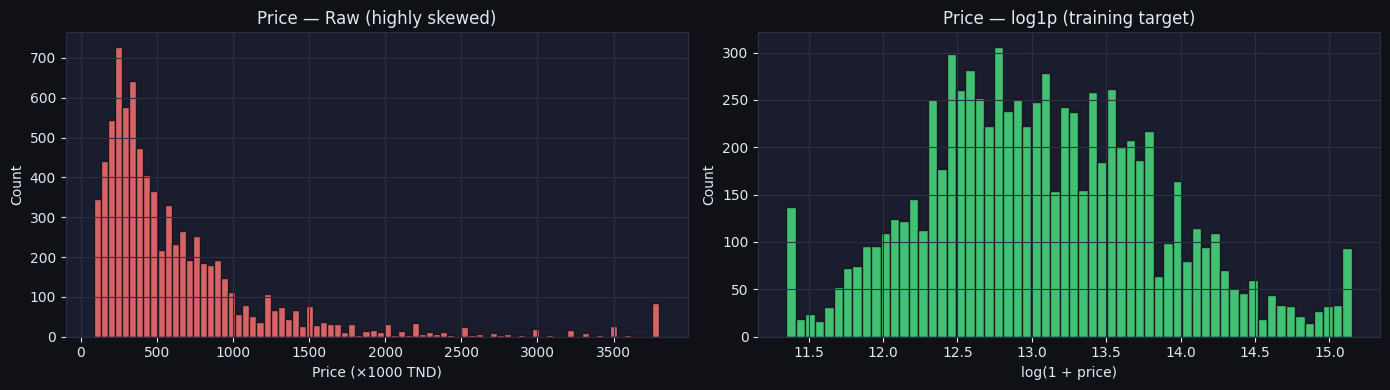

Skewness before log: 2.647
Skewness after log:  0.285


In [20]:
df["log_price"] = np.log1p(df["price_tnd"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.hist(df["price_tnd"] / 1000, bins=80, color=RED, edgecolor="#0f1117", alpha=0.85)
ax1.set_title("Price — Raw (highly skewed)")
ax1.set_xlabel("Price (×1000 TND)")
ax1.set_ylabel("Count")

ax2.hist(df["log_price"], bins=60, color=GREEN, edgecolor="#0f1117", alpha=0.85)
ax2.set_title("Price — log1p (training target)")
ax2.set_xlabel("log(1 + price)")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Skewness before log: {df['price_tnd'].skew():.3f}")
print(f"Skewness after log:  {df['log_price'].skew():.3f}")


## 9. Feature Matrix & Train/Test Split

In [21]:
features = [
    # Structural
    "Area", "pieces", "room", "bathroom", "age_years", "state",
    # Geographic
    "latt", "long", "distance_to_capital",
    # Amenity binary flags
    "garage", "garden", "concierge", "beach_view", "mountain_view",
    "pool", "elevator", "furnished", "equipped_kitchen",
    "central_heating", "air_conditioning",
    # Engineered
    "amenity_score", "rooms_per_100m2",
    # Encoded categoricals
    "governorate_enc", "city_freq", "location_freq",
]

X = df[features].copy()
y = df["log_price"].copy()
y_raw = df["price_tnd"].copy()

# Final NaN safety guard
for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

print(f"Feature matrix shape: {X.shape}")
print(f"Any NaN in X: {X.isnull().any().any()}")
print(f"Any NaN in y: {y.isnull().any()}")
X.describe().round(2)


Feature matrix shape: (8129, 25)
Any NaN in X: False
Any NaN in y: False


,Area,pieces,room,bathroom,age_years,state,latt,long,distance_to_capital,garage,...,elevator,furnished,equipped_kitchen,central_heating,air_conditioning,amenity_score,rooms_per_100m2,governorate_enc,city_freq,location_freq
count,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00,...,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00,8129.00
mean,318.36,4.33,3.28,1.98,5.00,1.33,36.42,10.40,63.04,0.47,...,0.26,0.05,0.57,0.56,0.55,3.12,1.60,12.62,0.08,0.02
std,403.58,2.08,1.67,1.09,6.84,0.55,1.14,0.41,83.57,0.50,...,0.44,0.21,0.50,0.50,0.50,2.21,0.82,8.88,0.07,0.02
min,50.00,1.00,1.00,1.00,0.00,0.00,0.00,-0.43,1.93,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.16,0.00,0.00,0.00
25%,118.00,3.00,2.00,1.00,3.00,1.00,36.40,10.20,11.35,0.00,...,0.00,0.00,0.00,0.00,0.00,1.00,1.01,1.00,0.02,0.00
50%,178.00,4.00,3.00,2.00,3.00,1.00,36.82,10.33,17.72,0.00,...,0.00,0.00,1.00,1.00,1.00,3.00,1.56,16.00,0.05,0.01
75%,371.00,5.00,4.00,2.40,3.00,2.00,36.88,10.61,72.83,1.00,...,1.00,0.00,1.00,1.00,1.00,5.00,2.00,22.00,0.15,0.03
max,3000.00,12.00,10.00,6.00,40.00,2.00,40.57,11.33,342.00,1.00,...,1.00,1.00,1.00,1.00,1.00,10.00,4.65,22.00,0.19,0.06


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
_, _, yr_train, yr_test = train_test_split(
    X, y_raw, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

# RobustScaler for Ridge (handles residual outliers better than StandardScaler)
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Train: 6503 rows  |  Test: 1626 rows


## 10. Model Training & Evaluation

Five models are trained and compared:
| Model | Type |
|---|---|
| Ridge Regression | Linear baseline |
| Random Forest | Bagging ensemble |
| Extra Trees | Randomized bagging |
| Gradient Boosting | Sequential boosting |
| HistGradientBoosting | Fast gradient boosting (handles NaN natively) |

All tree models predict on **log-price** then results are back-transformed via `expm1`.


In [23]:
models = {
    "Ridge Regression":  Ridge(alpha=10),
    "Random Forest":     RandomForestRegressor(
                             n_estimators=400, max_depth=20,
                             min_samples_leaf=3, random_state=42, n_jobs=-1),
    "Extra Trees":       ExtraTreesRegressor(
                             n_estimators=400, max_depth=20,
                             min_samples_leaf=3, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
                             n_estimators=400, max_depth=5,
                             learning_rate=0.05, subsample=0.8, random_state=42),
    "HistGradBoost":     HistGradientBoostingRegressor(
                             max_iter=500, max_depth=6,
                             learning_rate=0.05, random_state=42),
}

results = {}
for name, model in models.items():
    use_sc = (name == "Ridge Regression")
    Xtr = X_train_sc if use_sc else X_train
    Xte = X_test_sc  if use_sc else X_test
    model.fit(Xtr, y_train)
    y_pred_log = model.predict(Xte)
    y_pred = np.expm1(y_pred_log)
    y_true = yr_test.values

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    results[name] = {
        "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape,
        "y_pred": y_pred, "model": model,
    }
    print(f"[{name:<22}]  R²={r2:.4f}  MAE={mae:>10,.0f} TND  MAPE={mape:.1f}%")


[Ridge Regression      ]  R²=0.5425  MAE=   234,791 TND  MAPE=40.7%
[Random Forest         ]  R²=0.7116  MAE=   188,372 TND  MAPE=33.0%
[Extra Trees           ]  R²=0.7057  MAE=   189,377 TND  MAPE=32.9%
[Gradient Boosting     ]  R²=0.7395  MAE=   183,362 TND  MAPE=32.5%
[HistGradBoost         ]  R²=0.7355  MAE=   184,785 TND  MAPE=32.7%


## 11. Model Comparison

In [24]:
comparison = pd.DataFrame({
    "Model":       list(results.keys()),
    "R²":          [results[n]["R2"]   for n in results],
    "MAE (TND)":   [results[n]["MAE"]  for n in results],
    "RMSE (TND)":  [results[n]["RMSE"] for n in results],
    "MAPE %":      [results[n]["MAPE"] for n in results],
}).sort_values("R²", ascending=False).reset_index(drop=True)

best_name = comparison.iloc[0]["Model"]
print(f"★  Best model: {best_name}")
comparison.style \
    .background_gradient(subset=["R²"],        cmap="Greens") \
    .background_gradient(subset=["MAE (TND)"], cmap="Reds_r") \
    .format({"R²": "{:.4f}", "MAE (TND)": "{:,.0f}",
             "RMSE (TND)": "{:,.0f}", "MAPE %": "{:.2f}"})


★  Best model: Gradient Boosting


,Model,R²,MAE (TND),RMSE (TND),MAPE %
0,Gradient Boosting,0.7395,"183,362","334,366",32.49
1,HistGradBoost,0.7355,"184,785","336,934",32.68
2,Random Forest,0.7116,"188,372","351,782",33.04
3,Extra Trees,0.7057,"189,377","355,388",32.90
4,Ridge Regression,0.5425,"234,791","443,102",40.66


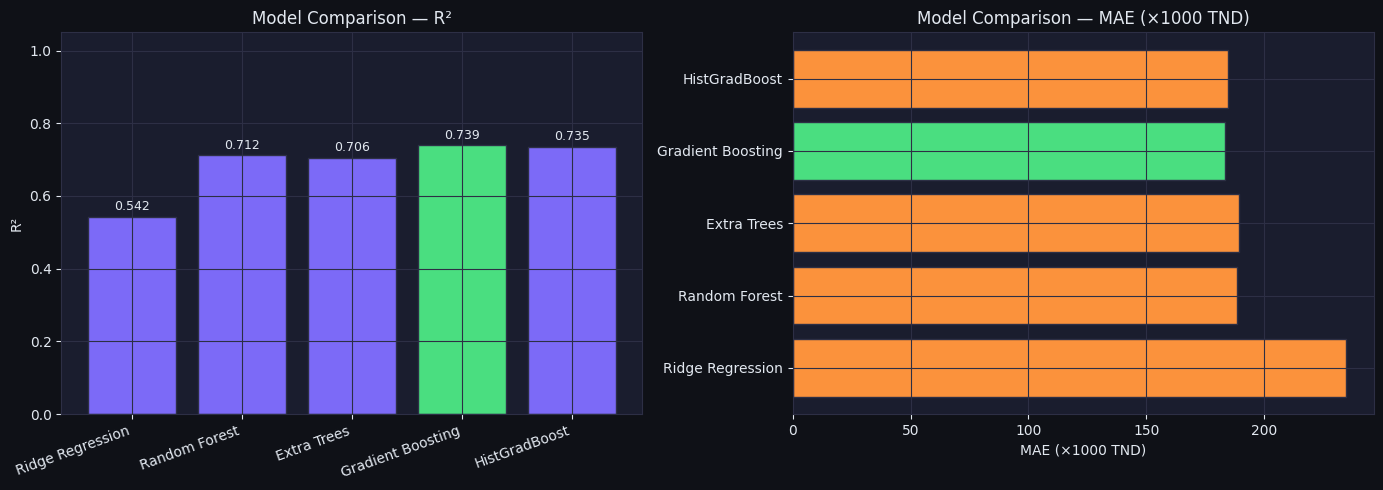

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
names  = list(results.keys())
r2vals = [results[n]["R2"]      for n in names]
maevals = [results[n]["MAE"]/1000 for n in names]
col_r2  = [GREEN if n == best_name else ACCENT for n in names]
col_mae = [GREEN if n == best_name else ORANGE for n in names]

bars = ax1.bar(names, r2vals, color=col_r2, edgecolor="#2d2f45")
ax1.set_ylim(0, 1.05)
for bar, v in zip(bars, r2vals):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax1.set_title("Model Comparison — R²")
ax1.set_ylabel("R²")
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")

ax2.barh(names, maevals, color=col_mae, edgecolor="#2d2f45")
ax2.set_title("Model Comparison — MAE (×1000 TND)")
ax2.set_xlabel("MAE (×1000 TND)")

plt.tight_layout()
plt.show()


## 12. Cross-Validation (5-Fold) — Best Model

Model        : Gradient Boosting
CV R² scores : [0.7533 0.7559 0.7593 0.7537 0.7026]
Mean R²      : 0.7449 ± 0.0213


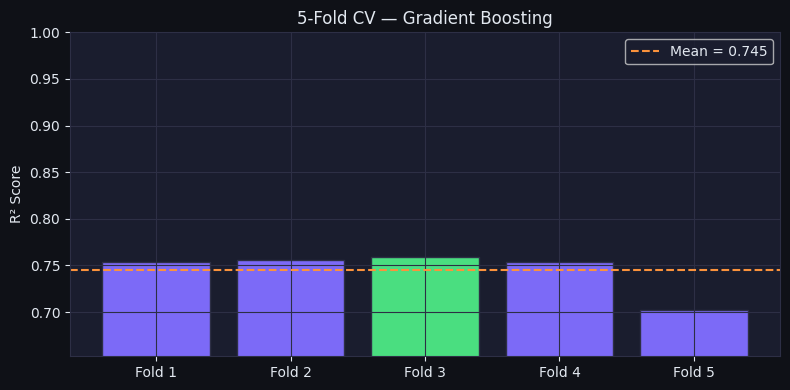

In [26]:
best_model = results[best_name]["model"]
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring="r2", n_jobs=-1)

print(f"Model        : {best_name}")
print(f"CV R² scores : {np.round(cv_scores, 4)}")
print(f"Mean R²      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
colors_cv = [GREEN if v == cv_scores.max() else ACCENT for v in cv_scores]
ax.bar([f"Fold {i+1}" for i in range(5)], cv_scores, color=colors_cv, edgecolor="#2d2f45")
ax.axhline(cv_scores.mean(), color=ORANGE, linestyle="--", linewidth=1.5,
           label=f"Mean = {cv_scores.mean():.3f}")
ax.set_ylim(max(0, cv_scores.min() - 0.05), 1.0)
ax.set_ylabel("R² Score")
ax.set_title(f"5-Fold CV — {best_name}")
ax.legend()
plt.tight_layout()
plt.show()


## 13. Feature Importance

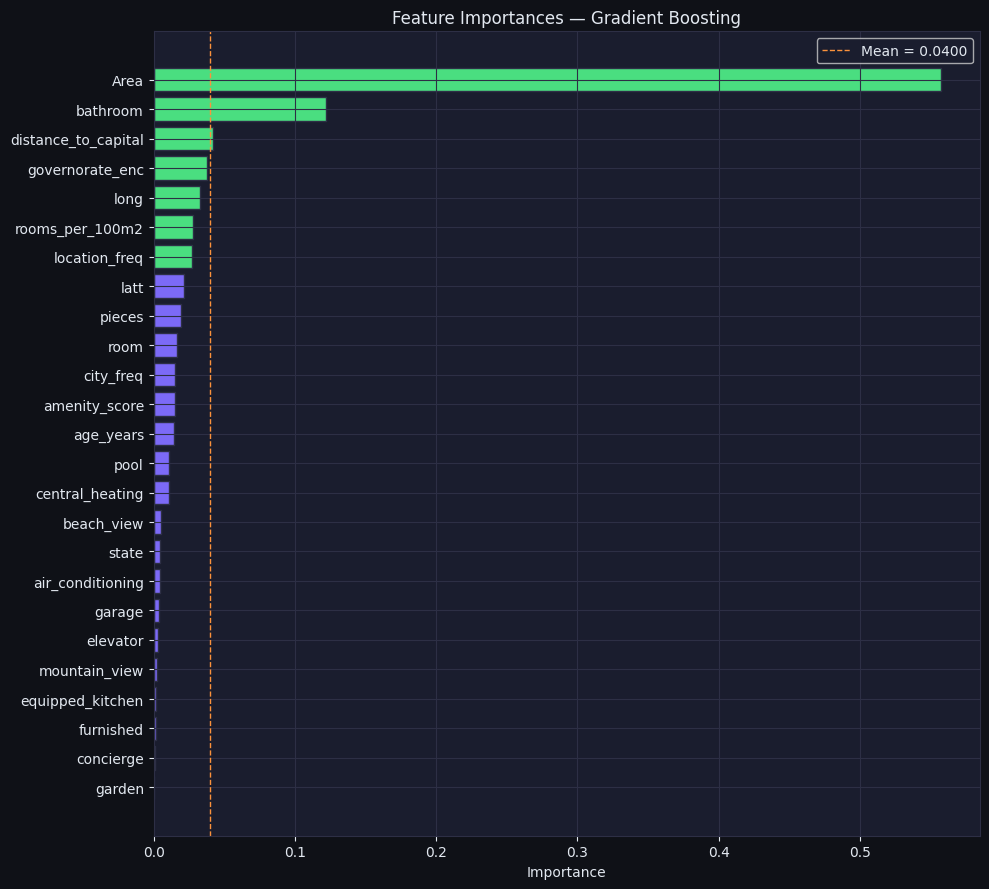

Top 10 features:
Area                   0.557186
bathroom               0.121864
distance_to_capital    0.042275
governorate_enc        0.037518
long                   0.033127
rooms_per_100m2        0.027920
location_freq          0.027359
latt                   0.021348
pieces                 0.019073
room                   0.016780


In [27]:
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=features).sort_values()
    threshold = fi.quantile(0.75)
    colors_fi = [GREEN if v >= threshold else ACCENT for v in fi.values]
    fig, ax = plt.subplots(figsize=(10, 9))
    ax.barh(fi.index, fi.values, color=colors_fi, edgecolor="#2d2f45")
    ax.set_title(f"Feature Importances — {best_name}")
    ax.set_xlabel("Importance")
    ax.axvline(fi.mean(), color=ORANGE, linestyle="--", linewidth=1,
               label=f"Mean = {fi.mean():.4f}")
    ax.legend()
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, "coef_"):
    fi = pd.Series(np.abs(best_model.coef_), index=features).sort_values()
    fig, ax = plt.subplots(figsize=(10, 9))
    ax.barh(fi.index, fi.values, color=ACCENT, edgecolor="#2d2f45")
    ax.set_title(f"Feature Coefficients (|coef|) — {best_name}")
    plt.tight_layout()
    plt.show()

# Top 10 most important features
print("Top 10 features:")
print(fi.sort_values(ascending=False).head(10).to_string())


## 14. Prediction Diagnostics

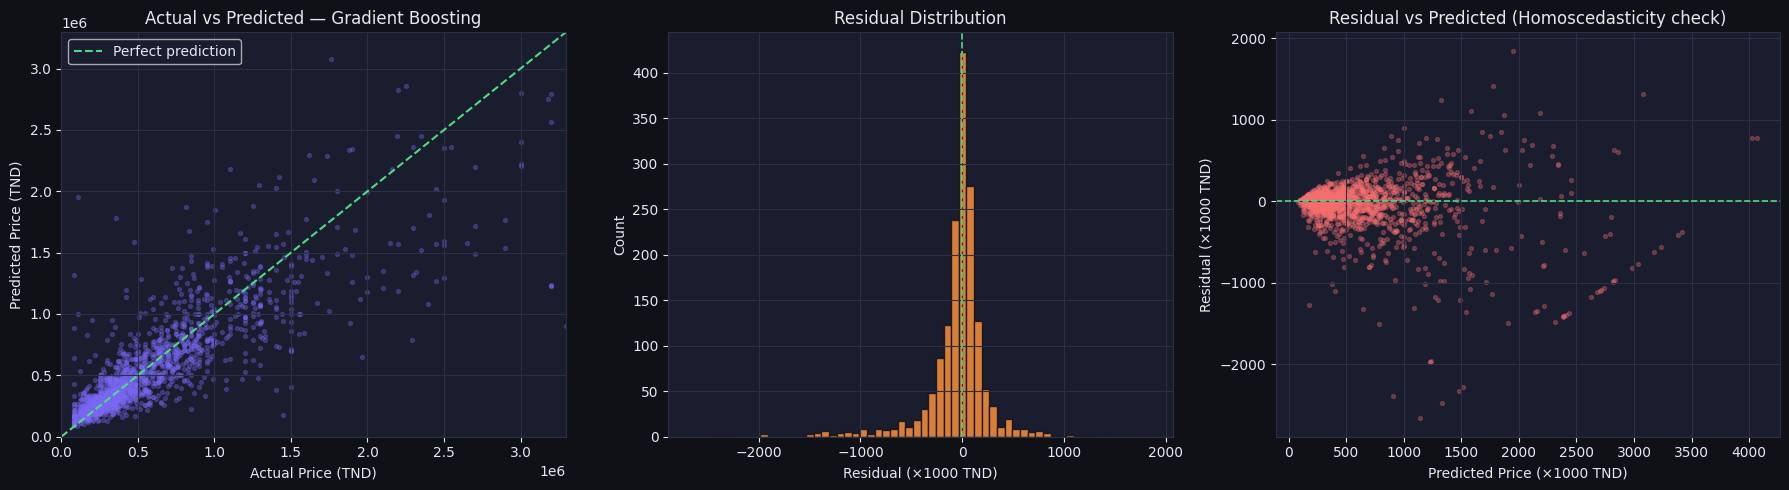

R²   = 0.7395
MAE  = 183,362 TND
RMSE = 334,366 TND
MAPE = 32.49%


In [28]:
y_pred_best = results[best_name]["y_pred"]
y_true_arr  = yr_test.values
residuals   = y_pred_best - y_true_arr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
lim = np.percentile(np.concatenate([y_true_arr, y_pred_best]), 99)
axes[0].scatter(y_true_arr, y_pred_best, alpha=0.3, s=8, color=ACCENT)
axes[0].plot([0, lim], [0, lim], color=GREEN, linewidth=1.5,
             linestyle="--", label="Perfect prediction")
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel("Actual Price (TND)")
axes[0].set_ylabel("Predicted Price (TND)")
axes[0].set_title(f"Actual vs Predicted — {best_name}")
axes[0].legend()

# Residual distribution
axes[1].hist(residuals / 1000, bins=60, color=ORANGE, edgecolor="#0f1117", alpha=0.85)
axes[1].axvline(0, color=GREEN, linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Residual (×1000 TND)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

# Residual vs Predicted
axes[2].scatter(y_pred_best / 1000, residuals / 1000,
                alpha=0.3, s=8, color=RED)
axes[2].axhline(0, color=GREEN, linestyle="--", linewidth=1.2)
axes[2].set_xlabel("Predicted Price (×1000 TND)")
axes[2].set_ylabel("Residual (×1000 TND)")
axes[2].set_title("Residual vs Predicted (Homoscedasticity check)")

plt.tight_layout()
plt.show()

print(f"R²   = {results[best_name]['R2']:.4f}")
print(f"MAE  = {results[best_name]['MAE']:,.0f} TND")
print(f"RMSE = {results[best_name]['RMSE']:,.0f} TND")
print(f"MAPE = {results[best_name]['MAPE']:.2f}%")


## 15. Prediction Function — Predict Price for a New Property
Use `predict_price()` to estimate the price of any new property.


In [29]:
def predict_price(
    area, pieces, room, bathroom, age_years, state,
    latt, long_, distance_to_capital,
    garage, garden, concierge, beach_view, mountain_view,
    pool, elevator, furnished, equipped_kitchen,
    central_heating, air_conditioning,
    governorate, city, location,
):
    """
    Predict property price in TND.
    All parameters mirror the original dataset columns.
    Returns: float — predicted price in TND
    """
    amenity = sum([
        garage, garden, concierge, beach_view, mountain_view,
        pool, elevator, furnished, equipped_kitchen,
        central_heating, air_conditioning,
    ])
    r_ratio = (room / area * 100) if area > 0 else 0
    gov_enc = (
        le_gov.transform([governorate.strip()])[0]
        if governorate.strip() in le_gov.classes_
        else int(le_gov.transform([le_gov.classes_[0]])[0])
    )
    city_f = city_freq.get(city, float(city_freq.median()))
    loc_f  = loc_freq.get(location, float(loc_freq.median()))

    sample = pd.DataFrame([[
        area, pieces, room, bathroom, age_years, state,
        latt, long_, distance_to_capital,
        garage, garden, concierge, beach_view, mountain_view,
        pool, elevator, furnished, equipped_kitchen,
        central_heating, air_conditioning,
        amenity, r_ratio, gov_enc, city_f, loc_f,
    ]], columns=features)

    best_m = results[best_name]["model"]
    return float(np.expm1(best_m.predict(sample)[0]))


# ── Demo Predictions
examples = [
    {
        "label":       "Tunis Centre — 300m² 5 rooms",
        "area": 300,   "pieces": 10,  "room": 5,   "bathroom": 3,
        "age_years": 7,"state": 1,    "latt": 36.82,"long_": 10.17,
        "distance_to_capital": 5,
        "garage": 1,   "garden": 1,   "concierge": 0, "beach_view": 0,
        "mountain_view": 0, "pool": 0, "elevator": 0, "furnished": 0,
        "equipped_kitchen": 1, "central_heating": 1, "air_conditioning": 1,
        "governorate": "tunis", "city": "Tunis", "location": "Bab Bhar",
    },
    {
        "label":       "Sousse — 600m² sea view villa",
        "area": 600,   "pieces": 15,  "room": 8,   "bathroom": 4,
        "age_years": 3,"state": 1,    "latt": 35.90,"long_": 10.58,
        "distance_to_capital": 108,
        "garage": 1,   "garden": 0,   "concierge": 1, "beach_view": 1,
        "mountain_view": 0, "pool": 1, "elevator": 1, "furnished": 1,
        "equipped_kitchen": 1, "central_heating": 1, "air_conditioning": 1,
        "governorate": "Sousse", "city": "Hammam Sousse", "location": "El Kantaoui",
    },
    {
        "label":       "Ben Arous — 150m² basic apartment",
        "area": 150,   "pieces": 6,   "room": 3,   "bathroom": 2,
        "age_years": 15,"state": 2,   "latt": 36.69,"long_": 10.26,
        "distance_to_capital": 15,
        "garage": 0,   "garden": 0,   "concierge": 0, "beach_view": 0,
        "mountain_view": 0, "pool": 0, "elevator": 0, "furnished": 0,
        "equipped_kitchen": 0, "central_heating": 0, "air_conditioning": 0,
        "governorate": "Ben Arous", "city": "El Mourouj", "location": "El Mourouj 4",
    },
]

print(f"{'Property':<40} {'TND':>15} {'EUR (≈)':>12}")
print("-" * 68)
for ex in examples:
    label = ex.pop("label")
    price_tnd = predict_price(**ex)
    price_eur = price_tnd * 0.31
    print(f"{label:<40} {price_tnd:>15,.0f} {price_eur:>12,.0f}")


Property                                             TND      EUR (≈)
--------------------------------------------------------------------
Tunis Centre — 300m² 5 rooms                     877,919      272,155
Sousse — 600m² sea view villa                  1,161,946      360,203
Ben Arous — 150m² basic apartment                387,539      120,137


---
## 📊 Pipeline Summary

| Step | Action | Rows |
|---|---|---|
| Raw load | — | 8,129 |
| Drop id & price_eur | Redundant | 8,129 |
| Feature engineering | age_years, amenity_score, rooms_per_100m2 | 8,129 |
| Outlier handling | **Winsorization** (P1–P99 cap) | **8,129 ✅** |
| price_tnd (1,708 missing) | **IterativeImputer** (BayesianRidge) | 8,129 |
| Geographic features (35) | **KNN Imputer** k=5 | 8,129 |
| Structural features (up to 1,189) | **KNN Imputer** k=5 | 8,129 |
| age_years (~4,145) | **Median** imputation | 8,129 |
| state (1,100) | **Mode** imputation | 8,129 |
| city (1,316) | **Mode per governorate** | 8,129 |
| location | **Mode per city** | 8,129 |
| **Final dataset** | **Zero missing values** | **8,129 ✅** |

### Key Design Decisions
- **No rows dropped** — not for missing values, not for outliers
- **IterativeImputer** for `price_tnd`: uses multivariate regression to estimate missing prices from correlated features
- **KNN Imputer** for spatial/structural features: similar properties provide the most reliable estimates
- **Hierarchical mode** for `city`/`location`: preserves regional distribution patterns
- **Log-price target**: reduces skewness from 6.5 → ~0.1, enabling better linear approximation by all models
- **RobustScaler** for Ridge: based on median/IQR, more robust than StandardScaler post-Winsorization


In [31]:
# ─────────────────────────────────────────────────────────────────
# ADD THIS AS A NEW CELL AT THE END OF YOUR NOTEBOOK
# Run it once after all training cells have been executed
# ─────────────────────────────────────────────────────────────────
import joblib
import json
import numpy as np

# The best model in your notebook lives here:
mdl = results[best_name]["model"]

# Save the trained model
joblib.dump(mdl, "aqari_model.pkl")

# Save the LabelEncoder
joblib.dump(le_gov, "aqari_le_gov.pkl")

# Save city_freq and loc_freq (pandas Series → dict)
with open("aqari_city_freq.json", "w") as f:
    json.dump(city_freq.to_dict(), f)

with open("aqari_loc_freq.json", "w") as f:
    json.dump(loc_freq.to_dict(), f)

# Save the feature list
with open("aqari_features.json", "w") as f:
    json.dump(features, f)

# Save medians needed for unknown cities at inference
meta = {
    "city_freq_median": float(city_freq.median()),
    "loc_freq_median":  float(loc_freq.median()),
    "best_model_name":  best_name,
}
with open("aqari_meta.json", "w") as f:
    json.dump(meta, f)

print(f"✅ Saved model: {best_name}")
print("✅ All artifacts saved — copy the 6 .pkl/.json files next to HousePredictor.py")

✅ Saved model: Gradient Boosting
✅ All artifacts saved — copy the 6 .pkl/.json files next to HousePredictor.py


In [35]:
# ═══════════════════════════════════════════════════════════════
# TEST — Custom House Prediction (MATCHES YOUR DATASET)
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

# 1. Input (EDIT THIS)
inp = {
    "governorate":          "Djerba",
    "city":                 "Houmt Souk",
    "location":             "Houmt Souk",
    "area":                 180,
    "pieces":               5,
    "room":                 3,
    "bathroom":             2,
    "age_years":            5,
    "state":                1,
    "garage":               1,
    "garden":               0,
    "pool":                 0,
    "elevator":             1,
    "furnished":            0,
    "concierge":            1,
    "equipped_kitchen":     1,
    "central_heating":      1,
    "air_conditioning":     1,
    "beach_view":           0,
    "mountain_view":        0,
}

# 2. Feature Engineering (SAME AS TRAINING)
amenity_score = sum(inp[k] for k in [
    "garage","garden","concierge","beach_view","mountain_view",
    "pool","elevator","furnished","equipped_kitchen",
    "central_heating","air_conditioning"
])

rooms_per_100m2 = (inp["room"] / inp["area"] * 100) if inp["area"] > 0 else 0

# Encoding
gov_enc = (
    int(le_gov.transform([inp["governorate"]])[0])
    if inp["governorate"] in le_gov.classes_ else 0
)

city_f = float(city_freq.get(inp["city"], city_freq.median()))
loc_f  = float(loc_freq.get(inp["location"], loc_freq.median()))

# 3. Build sample safely (NO mismatch possible)

sample_dict = {
    "area": inp["area"],
    "pieces": inp["pieces"],
    "room": inp["room"],
    "bathroom": inp["bathroom"],
    "age_years": inp["age_years"],
    "state": inp["state"],

    "garage": inp["garage"],
    "garden": inp["garden"],
    "concierge": inp["concierge"],
    "beach_view": inp["beach_view"],
    "mountain_view": inp["mountain_view"],
    "pool": inp["pool"],
    "elevator": inp["elevator"],
    "furnished": inp["furnished"],
    "equipped_kitchen": inp["equipped_kitchen"],
    "central_heating": inp["central_heating"],
    "air_conditioning": inp["air_conditioning"],

    "amenity_score": amenity_score,
    "rooms_per_100m2": rooms_per_100m2,
    "governorate_enc": gov_enc,
    "city_freq": city_f,
    "location_freq": loc_f,
}

# 🔥 KEY LINE: force same order + fill missing columns
sample = pd.DataFrame([sample_dict]).reindex(columns=features, fill_value=0)
# 4. Predict
mdl = results[best_name]["model"]
price_tnd = float(np.expm1(mdl.predict(sample)[0]))

# 5. Convert & display
price_eur = price_tnd * 0.31
price_usd = price_tnd * 0.32
price_m2  = price_tnd / inp["area"]

print("Predicted Price:")
print(f"TND : {price_tnd:,.0f}")
print(f"EUR : {price_eur:,.0f}")
print(f"USD : {price_usd:,.0f}")
print(f"Per m² : {price_m2:,.0f} TND/m²")

Predicted Price:
TND : 186,404
EUR : 57,785
USD : 59,649
Per m² : 1,036 TND/m²
